# General stuff
## Import required libraries

In [7]:
!pwd

/home/ylnner/Documents/omnet++/omnetpp-6.3.0/projects/florasat_v4_ult_routing/simulations/Test_Individual/results


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import matplotlib.image as mpimg
from scipy.spatial.distance import cdist

number_of_runs = 10

# wMLImplementation_2_scalar 
# Load the CSV files 
vector_files = [f"wMLImplementation_{i}_vector.csv" for i in range(0, number_of_runs)]
scalar_files = [f"wMLImplementation_{i}_scalar.csv" for i in range(0, number_of_runs)]

vector_dfs = [pd.read_csv(f) for f in vector_files]
scalar_dfs = [pd.read_csv(f) for f in scalar_files]

# Extract the first run data
dataR1 = vector_dfs[0]
scalar_df = scalar_dfs[0]


''' 
raan_values = [165, 175, 185, 195, 205]
# Inicializamos diccionarios para guardar los DataFrames estructurados
vector_dfs = {}
scalar_dfs = {}

# Cargamos todos los archivos dinámicamente usando un doble bucle
for raan in raan_values:
    for i in range(0, number_of_runs):
        # Construimos los nombres con el nuevo formato
        v_file = f"wMLImplementation_raan{raan}_{i}_vector.csv"
        s_file = f"wMLImplementation_raan{raan}_{i}_scalar.csv"
        
        # Leemos y guardamos en el diccionario usando la tupla (raan, run) como clave
        vector_dfs[(raan, i)] = pd.read_csv(v_file)
        scalar_dfs[(raan, i)] = pd.read_csv(s_file)

'''

' \nraan_values = [165, 175, 185, 195, 205]\n# Inicializamos diccionarios para guardar los DataFrames estructurados\nvector_dfs = {}\nscalar_dfs = {}\n\n# Cargamos todos los archivos dinámicamente usando un doble bucle\nfor raan in raan_values:\n    for i in range(0, number_of_runs):\n        # Construimos los nombres con el nuevo formato\n        v_file = f"wMLImplementation_raan{raan}_{i}_vector.csv"\n        s_file = f"wMLImplementation_raan{raan}_{i}_scalar.csv"\n\n        # Leemos y guardamos en el diccionario usando la tupla (raan, run) como clave\n        vector_dfs[(raan, i)] = pd.read_csv(v_file)\n        scalar_dfs[(raan, i)] = pd.read_csv(s_file)\n\n'

## Extract and Plot Node Positions

Node 0: Latitude = 54.978, Longitude = -1.617
Node 1: Latitude = 52.63, Longitude = -1.139
Node 2: Latitude = 52.612, Longitude = -6.295
Node 3: Latitude = 47.243, Longitude = 6.024
Node 4: Latitude = 43.61, Longitude = 3.876
Node 5: Latitude = 49.443, Longitude = 1.099
Node 6: Latitude = 37.992, Longitude = -1.13
Node 7: Latitude = 40.965, Longitude = -5.664
Node 8: Latitude = 40.657, Longitude = -7.914
Node 9: Latitude = 51.34, Longitude = 12.373
Node 10: Latitude = 51.455, Longitude = 7.011
Node 11: Latitude = 49.452, Longitude = 11.076
Node 12: Latitude = 43.769, Longitude = 11.255
Node 13: Latitude = 41.117, Longitude = 16.871
Node 14: Latitude = 52.132, Longitude = 5.291
Node 15: Latitude = 50.411, Longitude = 4.444
Node 16: Latitude = 47.559, Longitude = 7.588
Node 17: Latitude = 55.403, Longitude = 10.402
Node 18: Latitude = 59.858, Longitude = 17.638
Node 19: Latitude = 60.451, Longitude = 22.266
Node 20: Latitude = 56.325, Longitude = 22.349
Node 21: Latitude = 49.883, Longit

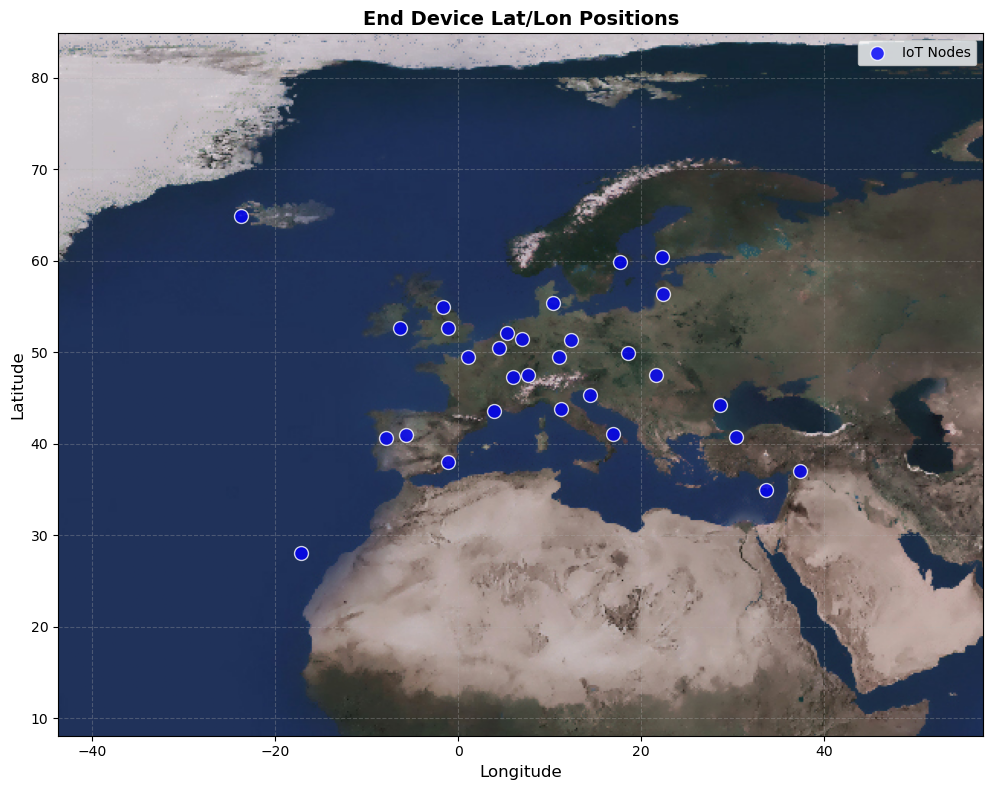

In [13]:
# Extract latitude and longitude for all nodes (limit to first 288 nodes)
latitudes = dataR1.loc[dataR1['attrname'].str.contains('mob.centerLatitude', na=False), 'attrvalue'].astype(float).tolist()[:288]
longitudes = dataR1.loc[dataR1['attrname'].str.contains('mob.centerLongitude', na=False), 'attrvalue'].astype(float).tolist()[:288]

# Create a dictionary to hold node positions (limit to 288 nodes)
node_positions = {}
for i in range(min(len(latitudes), 288)):
    node_positions[i] = (latitudes[i], longitudes[i])

# Print the node positions for debugging
for node_id, (lat, lon) in node_positions.items():
    print(f"Node {node_id}: Latitude = {lat}, Longitude = {lon}")

# Create a figure for plotting nodes on a map
plt.figure(figsize=(12, 8))

# Get current axis for later use
ax = plt.gca()

# Load the Earth background image
earth_img = mpimg.imread('background_earth_backup.png')

# Set the extent to the full range of possible coordinates
extent = [-180, 180, -90, 90]

# Display the background image
plt.imshow(earth_img, extent=extent, origin='upper', aspect='auto', zorder=0)

# Add some padding around the data points
padding = 20
min_lon, max_lon = min(longitudes) - padding, max(longitudes) + padding
min_lat, max_lat = min(latitudes) - padding, max(latitudes) + padding

# Set the plot limits to focus on our region of interest
plt.xlim(min_lon, max_lon)
plt.ylim(min_lat, max_lat)

# Plot IoT nodes with improved visibility
plt.scatter(longitudes, latitudes, c='blue', s=100, label='IoT Nodes', 
            alpha=0.8, edgecolors='white', zorder=10)

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('End Device Lat/Lon Positions', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')

# Ensure the aspect ratio of the plot maintains proper geographical proportions
ax.set_aspect('equal' if max_lon - min_lon < 180 else 'auto')

plt.tight_layout()
plt.show()


## Extract and Plot GS Positions

Ground Station 0: Latitude = 55.752, Longitude = 37.616
Ground Station 1: Latitude = 28.652, Longitude = 77.231
Ground Station 2: Latitude = 25.35, Longitude = 51.24
Earth background image loaded successfully


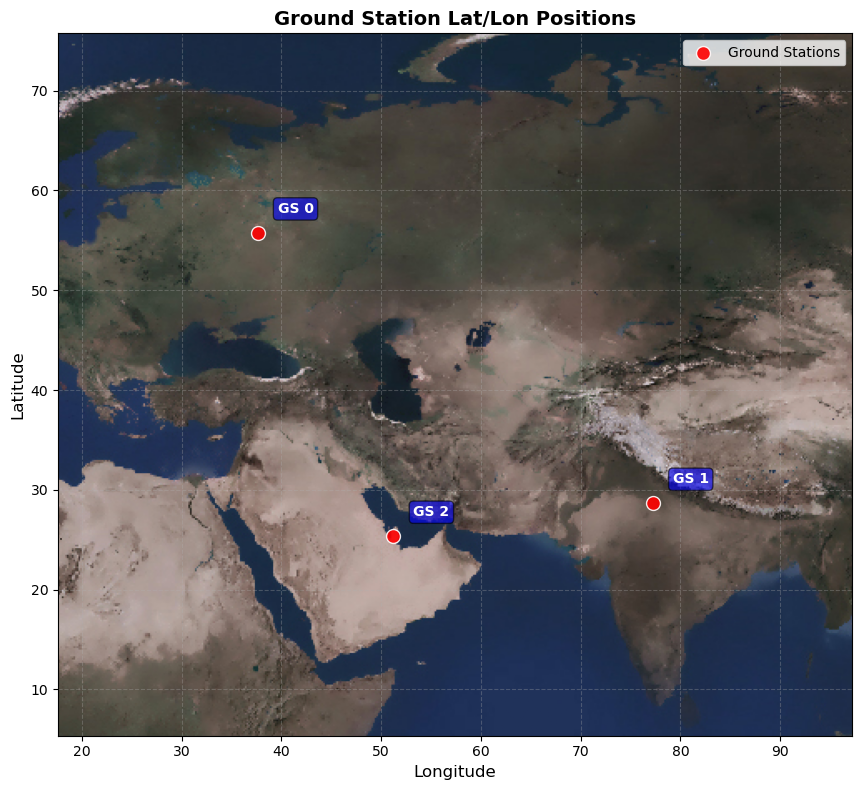

In [14]:
# Extract valid node IDs, handle ranges like [0..0] by taking the first number
def extract_valid_node_id(attrname):
    try:
        node_part = attrname.split('[')[1].split(']')[0]
        if '..' in node_part:  # Handle ranges
            return int(node_part.split('..')[0])  # Take the first number before ..
        return int(node_part)  # Return regular node ID
    except:
        return None

# Extract latitude and longitude for all GS
latitudes = dataR1.loc[dataR1['attrname'].str.contains('mobility.latitude', na=False), 'attrvalue'].astype(float).tolist()
longitudes = dataR1.loc[dataR1['attrname'].str.contains('mobility.longitude', na=False), 'attrvalue'].astype(float).tolist()

# Extract ground station IDs
gs_ids = dataR1.loc[dataR1['attrname'].str.contains('mobility.latitude', na=False), 'attrname'].apply(extract_valid_node_id).tolist()

# Create a dictionary to hold ground station positions
gs_positions = {}
for i in range(len(latitudes)):
    gs_positions[gs_ids[i]] = (latitudes[i], longitudes[i])
# Print the ground station positions for debugging
for gs_id, (lat, lon) in gs_positions.items():
    print(f"Ground Station {gs_id}: Latitude = {lat}, Longitude = {lon}")

# Create a new figure with a specific aspect ratio for geographical plotting
plt.figure(figsize=(12, 8))

# Get current axis for later use
ax = plt.gca()

# Load the Earth background image
import matplotlib.image as mpimg
earth_img = mpimg.imread('background_earth_backup.png')

# Get image dimensions
img_height, img_width = earth_img.shape[0], earth_img.shape[1]

# Set the extent to the full range of possible coordinates
# to preserve the earth map projection
extent = [-180, 180, -90, 90]

# Display the background image with its natural aspect ratio
plt.imshow(earth_img, extent=extent, origin='upper', aspect='auto', zorder=0)

# After showing the Earth map, set the limits to focus on our data
# Add some padding around the data points
padding = 20
min_lon, max_lon = min(longitudes) - padding, max(longitudes) + padding
min_lat, max_lat = min(latitudes) - padding, max(latitudes) + padding

# Set the plot limits to focus on our region of interest
plt.xlim(min_lon, max_lon)
plt.ylim(min_lat, max_lat)

print("Earth background image loaded successfully")


# Plot ground stations on top of the background with improved visibility
plt.scatter(longitudes, latitudes, c='red', s=100, label='Ground Stations', 
            alpha=0.9, edgecolors='white', zorder=10)

# Add station IDs as text labels next to each point
for i in range(len(gs_ids)):
    plt.text(longitudes[i] + 2, latitudes[i] + 2, f'GS {gs_ids[i]}', 
             fontsize=10, color='white', fontweight='bold',
             bbox=dict(facecolor='blue', alpha=0.6, boxstyle='round,pad=0.3'),
             zorder=11)

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('Ground Station Lat/Lon Positions', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')

# Ensure the aspect ratio of the plot maintains proper geographical proportions
# This is important for visualizing locations on a map
ax.set_aspect('equal' if max_lon - min_lon < 180 else 'auto')

plt.tight_layout()
plt.show()

## Identify Available Names

In [15]:
# List all unique attrname values to identify available metrics
unique_attrnames = dataR1['name'].dropna().unique()

# Print unique attrnames for review
print("Unique Names in the Dataset:")
for attr in unique_attrnames:
    print(attr)

Unique Names in the Dataset:
Satellite Position when Repetition Received
Repetition Position for Node 358 at Satellite
All Nodes Repetition Generation Delay at Satellite
Repetition Generation Delay for Node 358 at Satellite
All Nodes Message Generation Delay at Satellite
Message Generation Delay for Node 358 at Satellite
packets received
dropped unroutable
packets dropped
Repetition Position for Node 103 at Satellite
Repetition Generation Delay for Node 103 at Satellite
Message Generation Delay for Node 103 at Satellite
Repetition Position for Node 58 at Satellite
Repetition Generation Delay for Node 58 at Satellite
Message Generation Delay for Node 58 at Satellite
Repetition Position for Node 223 at Satellite
Repetition Generation Delay for Node 223 at Satellite
Message Generation Delay for Node 223 at Satellite
Repetition Position for Node 463 at Satellite
Repetition Generation Delay for Node 463 at Satellite
Message Generation Delay for Node 463 at Satellite
Repetition Position for 

at ED: 
- numTransmission for ED: number of repetition sent
- transmittedRepetitions

at Sat:
- averageRepetitionDelayFromGenerationAtSat
- averageRepetitionDelayFromSendingAtSat
- repetitionFromNode_i: number of repetitions received from ED i at each Sat
- repetitionsProcessedAtSat
- uniqueNodes: how many nodes detected

at GS:
- totalMessagesReceivedAtGround
- messagesReceivedAtThisGS
- totalRepetitionsReceivedAtGround
- averageMessageDelayFromGenerationAtGS
- averageMessageDelayFromSendingAtGS
- maxDelayForMessagesAtGS
- estimatedLostFrames (not used)
- messagesReceivedAtRepetitioni: the number of messages that has been received which is the i-th repetition 

# Global Data Collection


# Read Metrics with ML model Transformer

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import matplotlib.image as mpimg
from scipy.spatial.distance import cdist

number_of_runs = 10

# wMLImplementation_2_scalar 
# Load the CSV files 
vector_files = [f"wMLImplementation_{i}_vector.csv" for i in range(0, number_of_runs)]
scalar_files = [f"wMLImplementation_{i}_scalar.csv" for i in range(0, number_of_runs)]

vector_dfs = [pd.read_csv(f) for f in vector_files]
scalar_dfs = [pd.read_csv(f) for f in scalar_files]

# Number of real Transmissions from device
run_stats_trx_at_dev = []
for run_idx, dataR in enumerate(scalar_dfs):
    transmitted_rep_df = dataR[dataR['name'].str.contains('numTransmissionsApproved', na=False)].copy()
    all_values = []
    for val in transmitted_rep_df['value']:
        # Extraemos los valores individuales de los nodos
        all_values.extend([float(v) for v in str(val).strip('"').split()])
    
    run_stats_trx_at_dev.append({
        'meanTrxAtDev': np.mean(all_values) if all_values else 0,
        'maxTrxAtDev': np.max(all_values) if all_values else 0,
        'minTrxAtDev': np.min(all_values) if all_values else 0,
        'countTrxAtDev': int(sum(all_values))
    })

# Number of sucessfull receptios at satellite
run_stats_trx_at_sat = []
for run_idx, dataR in enumerate(scalar_dfs):
    transmitted_rep_df = dataR[dataR['name'].str.contains('Number of successful receptions', na=False)].copy()
    all_values = []
    for val in transmitted_rep_df['value']:
        # Extraemos los valores individuales de los nodos
        all_values.extend([float(v) for v in str(val).strip('"').split()])
    
    run_stats_trx_at_sat.append({
        'meanTrxAtSat': np.mean(all_values) if all_values else 0,
        'maxTrxAtSat': np.max(all_values) if all_values else 0,
        'minTrxAtSat': np.min(all_values) if all_values else 0,
        'countTrxAtSat': int(sum(all_values))
    })

# Total trx by seed assuming 30 devices and 45 repetitions
transmission_stats = []
for run_idx, data_scalar in enumerate(scalar_dfs):
    transmitted_repetitions = 30 * 45
    transmission_stats.append({
        'run': run_idx,
        'total_repetitions': transmitted_repetitions
    })


import pickle

with open("ML_trf_run_stats_trx_at_dev.pkl", "wb") as f:
    pickle.dump(run_stats_trx_at_dev, f)

with open("ML_trf_run_stats_trx_at_sat.pkl", "wb") as f:
    pickle.dump(run_stats_trx_at_sat, f)

with open("transmission_stats.pkl", "wb") as f:
    pickle.dump(transmission_stats, f)

# Read Metrics with ML model BiLSTM

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import matplotlib.image as mpimg
from scipy.spatial.distance import cdist

number_of_runs = 10

# wMLImplementation_2_scalar 
# Load the CSV files 
vector_files = [f"wMLImplementation_{i}_vector.csv" for i in range(0, number_of_runs)]
scalar_files = [f"wMLImplementation_{i}_scalar.csv" for i in range(0, number_of_runs)]

vector_dfs = [pd.read_csv(f) for f in vector_files]
scalar_dfs = [pd.read_csv(f) for f in scalar_files]

# Number of real Transmissions from device
run_stats_trx_at_dev = []
for run_idx, dataR in enumerate(scalar_dfs):
    transmitted_rep_df = dataR[dataR['name'].str.contains('numTransmissionsApproved', na=False)].copy()
    all_values = []
    for val in transmitted_rep_df['value']:
        # Extraemos los valores individuales de los nodos
        all_values.extend([float(v) for v in str(val).strip('"').split()])
    
    run_stats_trx_at_dev.append({
        'meanTrxAtDev': np.mean(all_values) if all_values else 0,
        'maxTrxAtDev': np.max(all_values) if all_values else 0,
        'minTrxAtDev': np.min(all_values) if all_values else 0,
        'countTrxAtDev': int(sum(all_values))
    })

# Number of sucessfull receptios at satellite
run_stats_trx_at_sat = []
for run_idx, dataR in enumerate(scalar_dfs):
    transmitted_rep_df = dataR[dataR['name'].str.contains('Number of successful receptions', na=False)].copy()
    all_values = []
    for val in transmitted_rep_df['value']:
        # Extraemos los valores individuales de los nodos
        all_values.extend([float(v) for v in str(val).strip('"').split()])
    
    run_stats_trx_at_sat.append({
        'meanTrxAtSat': np.mean(all_values) if all_values else 0,
        'maxTrxAtSat': np.max(all_values) if all_values else 0,
        'minTrxAtSat': np.min(all_values) if all_values else 0,
        'countTrxAtSat': int(sum(all_values))
    })

# Total trx by seed assuming 30 devices and 45 repetitions
transmission_stats = []
for run_idx, data_scalar in enumerate(scalar_dfs):
    transmitted_repetitions = 30 * 45
    transmission_stats.append({
        'run': run_idx,
        'total_repetitions': transmitted_repetitions
    })


import pickle

with open("ML_lstm_run_stats_trx_at_dev.pkl", "wb") as f:
    pickle.dump(run_stats_trx_at_dev, f)

with open("ML_lstm_run_stats_trx_at_sat.pkl", "wb") as f:
    pickle.dump(run_stats_trx_at_sat, f)

In [17]:
!pwd

/home/ylnner/Documents/omnet++/omnetpp-6.3.0/projects/florasat_v4_ult_routing/simulations/Test_Individual/results


# Read Metrics without ML model

In [5]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import matplotlib.image as mpimg
from scipy.spatial.distance import cdist

number_of_runs = 10

# wMLImplementation_2_scalar 
# Load the CSV files 
vector_files = [f"wMLImplementation_{i}_vector.csv" for i in range(0, number_of_runs)]
scalar_files = [f"wMLImplementation_{i}_scalar.csv" for i in range(0, number_of_runs)]

vector_dfs = [pd.read_csv(f) for f in vector_files]
scalar_dfs = [pd.read_csv(f) for f in scalar_files]

# Number of real Transmissions from device
run_stats_trx_at_dev = []
for run_idx, dataR in enumerate(scalar_dfs):
    transmitted_rep_df = dataR[dataR['name'].str.contains('numTransmissionsApproved', na=False)].copy()
    all_values = []
    for val in transmitted_rep_df['value']:
        # Extraemos los valores individuales de los nodos
        all_values.extend([float(v) for v in str(val).strip('"').split()])
    
    run_stats_trx_at_dev.append({
        'meanTrxAtDev': np.mean(all_values) if all_values else 0,
        'maxTrxAtDev': np.max(all_values) if all_values else 0,
        'minTrxAtDev': np.min(all_values) if all_values else 0,
        'countTrxAtDev': int(sum(all_values))
    })

# Number of sucessfull receptios at satellite
run_stats_trx_at_sat = []
for run_idx, dataR in enumerate(scalar_dfs):
    transmitted_rep_df = dataR[dataR['name'].str.contains('Number of successful receptions', na=False)].copy()
    all_values = []
    for val in transmitted_rep_df['value']:
        # Extraemos los valores individuales de los nodos
        all_values.extend([float(v) for v in str(val).strip('"').split()])
    
    run_stats_trx_at_sat.append({
        'meanTrxAtSat': np.mean(all_values) if all_values else 0,
        'maxTrxAtSat': np.max(all_values) if all_values else 0,
        'minTrxAtSat': np.min(all_values) if all_values else 0,
        'countTrxAtSat': int(sum(all_values))
    })

# Total trx by seed assuming 30 devices and 45 repetitions
transmission_stats = []
for run_idx, data_scalar in enumerate(scalar_dfs):
    transmitted_repetitions = 30 * 45
    transmission_stats.append({
        'run': run_idx,
        'total_repetitions': transmitted_repetitions
    })


import pickle
with open("noML_run_stats_trx_at_dev.pkl", "wb") as f:
    pickle.dump(run_stats_trx_at_dev, f)

with open("noML_run_stats_trx_at_sat.pkl", "wb") as f:
    pickle.dump(run_stats_trx_at_sat, f)

In [6]:
run_stats_trx_at_dev

[{'meanTrxAtDev': np.float64(41.43333333333333),
  'maxTrxAtDev': np.float64(44.0),
  'minTrxAtDev': np.float64(38.0),
  'countTrxAtDev': 1243},
 {'meanTrxAtDev': np.float64(41.86666666666667),
  'maxTrxAtDev': np.float64(46.0),
  'minTrxAtDev': np.float64(36.0),
  'countTrxAtDev': 1256},
 {'meanTrxAtDev': np.float64(41.93333333333333),
  'maxTrxAtDev': np.float64(44.0),
  'minTrxAtDev': np.float64(38.0),
  'countTrxAtDev': 1258},
 {'meanTrxAtDev': np.float64(42.13333333333333),
  'maxTrxAtDev': np.float64(46.0),
  'minTrxAtDev': np.float64(37.0),
  'countTrxAtDev': 1264},
 {'meanTrxAtDev': np.float64(42.266666666666666),
  'maxTrxAtDev': np.float64(44.0),
  'minTrxAtDev': np.float64(40.0),
  'countTrxAtDev': 1268},
 {'meanTrxAtDev': np.float64(42.13333333333333),
  'maxTrxAtDev': np.float64(46.0),
  'minTrxAtDev': np.float64(39.0),
  'countTrxAtDev': 1264},
 {'meanTrxAtDev': np.float64(42.1),
  'maxTrxAtDev': np.float64(47.0),
  'minTrxAtDev': np.float64(39.0),
  'countTrxAtDev': 1263

In [ ]:
print(len(run_stats_trx_at_dev))
run_stats_trx_at_dev

In [ ]:
print(len(run_stats_trx_at_sat))
run_stats_trx_at_sat

In [ ]:
!pip install seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame({
    'Run': [d['run'] for d in transmission_stats],
    'Generated': [d['total_repetitions'] for d in transmission_stats],
    'Transmitted': [d['countTrxAtDev'] for d in run_stats_trx_at_dev],
    'Successful': [d['countTrxAtSat'] for d in run_stats_trx_at_sat]
})

# 3. Calcular las métricas de comunicaciones e IA
df['PDR'] = df['Successful'] / df['Transmitted']
df['Drop_Rate'] = 1.0 - df['PDR']
df['False_Positive'] = df['Transmitted'] - df['Successful']
df['No_Transmitted'] = df['Generated'] - df['Transmitted']

#print("--- Métricas Calculadas por Run (Seed) ---")
#print(df.to_string(index=False))

# --- GRÁFICO 1: Distribución de PDR y Packet Drop Rate (Boxplot + Stripplot) ---
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2), sharey=False)

# Boxplot PDR
sns.boxplot(y=df['PDR'] * 100, ax=axes[0], color='#a1dab4', width=0.4, fliersize=0)
sns.stripplot(y=df['PDR'] * 100, ax=axes[0], color='#41b6c4', size=6, jitter=0.15, edgecolor='black', linewidth=0.5)
axes[0].set_title('Packet Delivery Ratio (PDR)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].grid(True)

# Boxplot Drop Rate
sns.boxplot(y=df['Drop_Rate'] * 100, ax=axes[1], color='#fbb4b9', width=0.4, fliersize=0)
sns.stripplot(y=df['Drop_Rate'] * 100, ax=axes[1], color='#f768a1', size=6, jitter=0.15, edgecolor='black', linewidth=0.5)
axes[1].set_title('Packet Drop Rate')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('comms_performance_metrics.pdf', dpi=300, bbox_inches='tight')
plt.show()

# --- GRÁFICO 2: Análisis de Paquetes (Flujo de Decisiones e Ineficiencia) ---
fig, ax1 = plt.subplots(figsize=(6, 3.5))

# Configuración de barras apiladas o comparativas por Run
x = df['Run']
width = 0.35

# Queremos ver cuántos se quedaron en el dispositivo vs cuántos causaron Falsos Positivos
rects1 = ax1.bar(x - width/2, df['No_Transmitted'], width, label='Mensajes No Transmitidos (Retenidos)', color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.5)
rects2 = ax1.bar(x + width/2, df['False_Positive'], width, label='Falsos Positivos (Trx. Fallidas)', color='#d62728', alpha=0.85, edgecolor='black', linewidth=0.5)

ax1.set_xlabel('ID de la Simulación (Seed / Run)')
ax1.set_ylabel('Cantidad de Paquetes')
ax1.set_title('Análisis de Decisiones del Modelo por Corrida')
ax1.set_xticks(x)
ax1.legend(loc='upper right')
ax1.grid(True, axis='y')

plt.tight_layout()
plt.savefig('decision_and_fp_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df = pd.DataFrame({
    'Run': [d['run'] for d in transmission_stats],
    'Generated': [d['total_repetitions'] for d in transmission_stats],
    'Transmitted': [d['countTrxAtDev'] for d in run_stats_trx_at_dev],
    'Successful': [d['countTrxAtSat'] for d in run_stats_trx_at_sat]
})

# 3. Calcular las métricas de comunicaciones e IA
df['PDR'] = df['Successful'] / df['Transmitted']
df['Drop_Rate'] = 1.0 - df['PDR']
df['False_Positive'] = df['Transmitted'] - df['Successful']
df['No_Transmitted'] = df['Generated'] - df['Transmitted']



df = pd.DataFrame({
    'Run': [d['run'] for d in transmission_stats],
    'Transmitted': [d['countTrxAtDev'] for d in run_stats_trx_at_dev],
    'Successful': [d['countTrxAtSat'] for d in run_stats_trx_at_sat]
})

df['PDR_porc'] = (df['Successful'] / df['Transmitted']) * 100
df['Drop_porc'] = 100.0 - df['PDR_porc']
# =========================================================================
# GRÁFICO 1: Líneas comparativas (PDR vs Drop Rate a lo largo de los Runs)
# =========================================================================
plt.figure(figsize=(6.5, 3.8))
runs = df['Run']

plt.plot(runs, df['PDR_porc'], marker='o', linewidth=2, color='#0072B2', label='Packet Delivery Ratio (PDR)')
plt.plot(runs, df['Drop_porc'], marker='s', linewidth=2, color='#D55E00', label='Packet Drop Rate')

# Añadir etiquetas de valor sobre los puntos para máxima claridad
for i, (pdr, drop) in enumerate(zip(df['PDR_porc'], df['Drop_porc'])):
    plt.annotate(f"{pdr:.1f}%", (runs[i], pdr), textcoords="offset points", xytext=(0,8), ha='center', fontsize=8, color='#0072B2', weight='bold')
    plt.annotate(f"{drop:.1f}%", (runs[i], drop), textcoords="offset points", xytext=(0,-12), ha='center', fontsize=8, color='#D55E00', weight='bold')

plt.title('Rendimiento del Canal por Corrida de Simulación (Seed)')
plt.xlabel('ID de la Simulación (Run / Seed)')
plt.ylabel('Porcentaje de Paquetes (%)')
plt.xticks(runs)
plt.ylim(-5, 115) # Espacio para que no se corten las etiquetas
plt.legend(loc='center right')
plt.grid(True)
plt.tight_layout()
plt.savefig('pdr_vs_drop_lines.pdf', dpi=300)
plt.show()

# =========================================================================
# GRÁFICO 2: Barras Apiladas al 100% (Composición del destino del paquete)
# =========================================================================
plt.figure(figsize=(6.5, 3.8))

# Barra del Drop Rate (abajo) y barra del PDR (encima, sumando hasta 100)
plt.bar(runs, df['Drop_porc'], label='Packet Drop Rate (Perdidos)', color='#fbb4b9', edgecolor='black', linewidth=0.5, width=0.6)
plt.bar(runs, df['PDR_porc'], bottom=df['Drop_porc'], label='Packet Delivery Ratio (Exitosos)', color='#b3cde3', edgecolor='black', linewidth=0.5, width=0.6)

plt.title('Composición Porcentual del Destino de las Transmisiones')
plt.xlabel('ID de la Simulación (Run / Seed)')
plt.ylabel('Distribución de Transmisiones Realizadas (%)')
plt.xticks(runs)
plt.ylim(0, 100)
plt.legend(loc='lower left')
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig('pdr_vs_drop_stacked.pdf', dpi=300)
plt.show()

In [ ]:
run_stats_rep_at_sat = []
dataR = vector_dfs[0]
nodeGenDelayRep_df = dataR[dataR['name'].str.contains('All Nodes Repetition Generation Delay at Satellite', na=False)].copy()
all_delays = []
for vec in nodeGenDelayRep_df['vecvalue']:
    all_delays.extend([float(val) for val in str(vec).strip('"').split()])
    run_stats_rep_at_sat.append({
        'meanRepAtSat': np.mean(all_delays) if all_delays else 0,
        'maxRepAtSat': np.max(all_delays) if all_delays else 0,
        'minRepAtSat': np.min(all_delays) if all_delays else 0,
        'countRepAtSat': len(all_delays)
    })

print('='*50)
print(len(all_delays))
#all_delays
run_stats_rep_at_sat

In [ ]:
run_stats_rep_at_sat = []
for run_idx, dataR in enumerate(vector_dfs):
    nodeGenDelayRep_df = dataR[dataR['name'].str.contains('All Nodes Repetition Generation Delay at Satellite', na=False)].copy()
    all_delays = []
    for vec in nodeGenDelayRep_df['vecvalue']:
        all_delays.extend([float(val) for val in str(vec).strip('"').split()])
    run_stats_rep_at_sat.append({
        'meanRepAtSat': np.mean(all_delays) if all_delays else 0,
        'maxRepAtSat': np.max(all_delays) if all_delays else 0,
        'minRepAtSat': np.min(all_delays) if all_delays else 0,
        'countRepAtSat': len(all_delays)
    })

run_stats_rep_at_sat

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Listas para almacenar estadísticas por cada run
run_stats_msg_at_dev = []  # Ahora almacenará las estadísticas del escalar transmittedRepetitions
run_stats_rep_at_sat = []
run_stats_msg_at_sat = []


for run_idx, dataR in enumerate(scalar_dfs):
    transmitted_rep_df = dataR[dataR['name'].str.contains('transmittedRepetitions', na=False)].copy()
    all_values = []
    for val in transmitted_rep_df['value']:
        # Extraemos los valores individuales de los nodos
        all_values.extend([float(v) for v in str(val).strip('"').split()])
    
    run_stats_msg_at_dev.append({
        'meanMsgAtDev': np.mean(all_values) if all_values else 0,
        'maxMsgAtDev': np.max(all_values) if all_values else 0,
        'minMsgAtDev': np.min(all_values) if all_values else 0,
        'countMsgAtDev': int(sum(all_values))
    })

# Collect stats for "All Nodes Repetition Generation Delay at Satellite"
for run_idx, dataR in enumerate(vector_dfs):
    nodeGenDelayRep_df = dataR[dataR['name'].str.contains('All Nodes Repetition Generation Delay at Satellite', na=False)].copy()
    all_delays = []
    for vec in nodeGenDelayRep_df['vecvalue']:
        all_delays.extend([float(val) for val in str(vec).strip('"').split()])
    run_stats_rep_at_sat.append({
        'meanRepAtSat': np.mean(all_delays) if all_delays else 0,
        'maxRepAtSat': np.max(all_delays) if all_delays else 0,
        'minRepAtSat': np.min(all_delays) if all_delays else 0,
        'countRepAtSat': len(all_delays)
    })

# Collect stats for "All Nodes Message Generation Delay at Satellite"
for run_idx, dataR in enumerate(vector_dfs):
    nodeGenDelayRep_df = dataR[dataR['name'].str.contains('All Nodes Message Generation Delay at Satellite', na=False)].copy()
    all_delays = []
    for vec in nodeGenDelayRep_df['vecvalue']:
        all_delays.extend([float(val) for val in str(vec).strip('"').split()])
    run_stats_msg_at_sat.append({
        'meanMsgAtSat': np.mean(all_delays) if all_delays else 0,
        'maxMsgAtSat': np.max(all_delays) if all_delays else 0,
        'minMsgAtSat': np.min(all_delays) if all_delays else 0,
        'countMsgAtSat': len(all_delays)
    })

# Print stats for each run
for i in range(len(run_stats_msg_at_dev)):
    print(f"Run {i+1}: Mean Transmitted Reps: {run_stats_msg_at_dev[i]['meanMsgAtDev']:.2f}, Max: {run_stats_msg_at_dev[i]['maxMsgAtDev']:.2f}, Min: {run_stats_msg_at_dev[i]['minMsgAtDev']:.2f}, Count: {run_stats_msg_at_dev[i]['countMsgAtDev']}")
    print(f"Run {i+1}: Mean Rep at Sat: {run_stats_rep_at_sat[i]['meanRepAtSat']:.2f}s, Max Rep at Sat: {run_stats_rep_at_sat[i]['maxRepAtSat']:.2f}s, Min Rep at Sat: {run_stats_rep_at_sat[i]['minRepAtSat']:.2f}s, Messages Rep at Sat: {run_stats_rep_at_sat[i]['countRepAtSat']}")
    print(f"Run {i+1}: Mean Msg at Sat: {run_stats_msg_at_sat[i]['meanMsgAtSat']:.2f}s, Max Msg at Sat: {run_stats_msg_at_sat[i]['maxMsgAtSat']:.2f}s, Min Msg at Sat: {run_stats_msg_at_sat[i]['minMsgAtSat']:.2f}s, Messages Msg at Sat: {run_stats_msg_at_sat[i]['countMsgAtSat']}\n")

# Gráfico individual (Promedio de transmittedRepetitions por Run)
means = [stats['meanMsgAtDev'] for stats in run_stats_msg_at_dev]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(means) + 1), means, 'o-', label='Mean Transmitted Repetitions', color='navy')
plt.xlabel('Number of repetition')
plt.ylabel('Transmitted Repetitions')
plt.title('Average Transmitted Repetitions per Run')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
transmission_stats = []

for run_idx, data_scalar in enumerate(scalar_dfs):
    transmitted_messages = 60 * 6
    transmitted_repetitions = 60 * 6 * (run_idx + 1)

    transmission_stats.append({
        'run': run_idx + 1,
        'total_messages': transmitted_messages,
        'total_repetitions': transmitted_repetitions
    })

for stats in transmission_stats:
    print(f"Run {stats['run']}: Messages sent: {stats['total_messages']}, Repetitions sent: {stats['total_repetitions']}")

for i, stats in enumerate(run_stats_msg_at_dev):
    print(f"Run {i+1}: Transmitted Repetitions Count: {stats['countMsgAtDev']}")

for i, stats in enumerate(run_stats_rep_at_sat):
    print(f"Run {i+1}: Messages Rep at Sat: {stats['countRepAtSat']}")

for i, stats in enumerate(run_stats_msg_at_sat):
    print(f"Run {i+1}: Messages Msg at Sat: {stats['countMsgAtSat']}")

# Generación de gráficos en una cuadrícula de 2x2
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
ax1, ax2, ax3, ax4 = axs.flatten()

runs = [stats['run'] for stats in transmission_stats]
# Relación basada en el conteo de la nueva métrica escalar
delivery_ratio = (np.array([stats['countMsgAtDev'] for stats in run_stats_msg_at_dev]) / np.array([stats['total_messages'] for stats in transmission_stats])) * 100
repetitions = (np.array([stats['countRepAtSat'] for stats in run_stats_rep_at_sat]) / np.array([stats['total_repetitions'] for stats in transmission_stats])) * 100
delivery_ratio_at_Sat = (np.array([stats['countMsgAtSat'] for stats in run_stats_msg_at_sat]) / np.array([stats['total_messages'] for stats in transmission_stats])) * 100

# 1. Transmitted Repetitions Ratio
ax1.plot(runs, delivery_ratio, 'o-', label='Transmitted Repetitions Ratio', color='navy')
ax1.set_xlabel('Number of Repetition by Message')
ax1.set_ylabel('Ratio (%)')
ax1.set_title('Transmitted Repetitions Ratio by Number of Repetition by Message')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Extraction Rate
ax2.plot(runs, repetitions, 'o-', label='Extraction Rate', color='red')
ax2.set_xlabel('Number of Repetition by Message')
ax2.set_ylabel('Extraction Rate (%)')
ax2.set_title('Extraction Rate by Number of Repetition by Message')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Delivery Ratio at Sat
ax3.plot(runs, delivery_ratio_at_Sat, 'o-', label='Delivery Ratio of Messages at Sat', color='green')
ax3.set_xlabel('Number of Repetition by Message')
ax3.set_ylabel('Delivery Ratio (%)')
ax3.set_title('Delivery Ratio of Messages at Sat by Number of Repetition by Message')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Ocultar el cuarto cuadrante (ya que no manejamos numCollisions)
ax4.axis('off')

plt.tight_layout()
plt.show()